In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint
from sklearn.metrics import precision_recall_curve, average_precision_score
from tqdm import tqdm
import shap

/Users/aakritiyadav/Desktop/Product/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df= pd.read_csv("/Users/aakritiyadav/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df= df.drop(["customerID"],axis=1)

In [9]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df["TotalCharges"]= pd.to_numeric(df["TotalCharges"], errors='coerce')

In [11]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [12]:
(df["TotalCharges"] == 0).sum()

np.int64(0)

In [13]:
# you can either drop the NaN values or fill those values with the mean 
df.dropna(subset=["TotalCharges"], inplace=True)

In [14]:
df.loc[df["TotalCharges"].isna(), "TotalCharges"]

Series([], Name: TotalCharges, dtype: float64)

In [15]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [16]:
df.select_dtypes(include=['number']).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [17]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [18]:
df["SeniorCitizen"]= df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df[df["gender"] == "Female"].groupby("gender")["Churn"].count()

gender
Female    3483
Name: Churn, dtype: int64

In [20]:
df["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [21]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

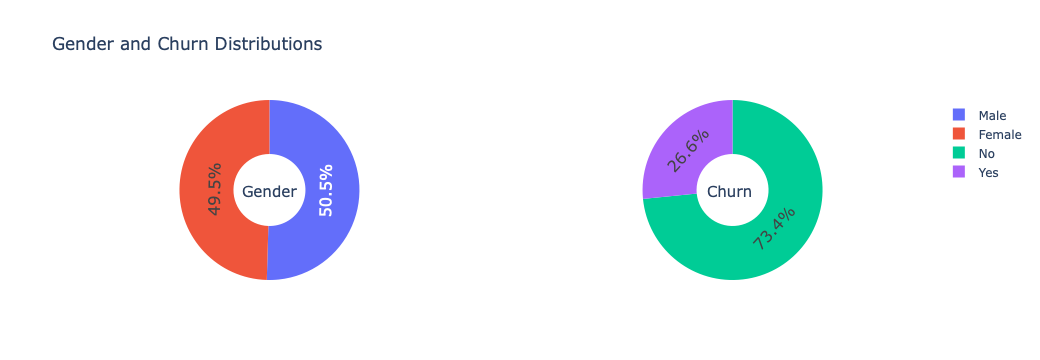

In [22]:
g_labels = df["gender"].value_counts()
c_labels = df["Churn"].value_counts()

fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])

fig.add_trace(
    go.Pie(labels=g_labels.index, 
           values=g_labels, 
           name="Gender"),
              1, 1
)
fig.add_trace(
    go.Pie(labels=c_labels.index, 
           values=c_labels, 
           name="Churn"),
              1, 2)

fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)

fig.update_layout(
    title_text="Gender and Churn Distributions",
    annotations=[dict(text='Gender', x=0.19, y=0.5, font_size=15, showarrow=False),
                 dict(text='Churn', x=0.80, y=0.5, font_size=15, showarrow=False)])

fig.show()

In [23]:
# Get churn distribution by gender
f_labels = df[df["gender"] == "Female"]["Churn"].value_counts()
m_labels = df[df["gender"] == "Male"]["Churn"].value_counts()
colors = ["lightgreen", "lightcoral"]

fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])

fig.add_trace(
    go.Pie(labels=f_labels.index, values=f_labels.values, name="Female"),
    1, 1
)

fig.add_trace(
    go.Pie(labels=m_labels.index, values=m_labels.values, name="Male", marker=dict(colors=colors)),
    1, 2
)

fig.update_traces(hole=0.4, textinfo="label+percent")
fig.update_layout(
    title="Churn Distribution by Gender",
    annotations=[
        dict(text='Female', x=0.20, y=0.5, showarrow=False),
        dict(text='Male', x=0.79, y=0.5, showarrow=False)
    ]
)

fig.show()

In [24]:
# df.groupby(['gender', 'Churn']).size()
# df[['gender', 'Churn']].value_counts().unstack()
df.groupby('gender')['Churn'].value_counts().unstack()

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


In [25]:
df[df["Churn"] == "Yes"].groupby("gender")["Churn"].count()

gender
Female    939
Male      930
Name: Churn, dtype: int64

In [26]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [27]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [28]:
df.groupby('Contract')['PaymentMethod'].value_counts().unstack()

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,589,543,1850,893
One year,391,398,347,336
Two year,562,580,168,375


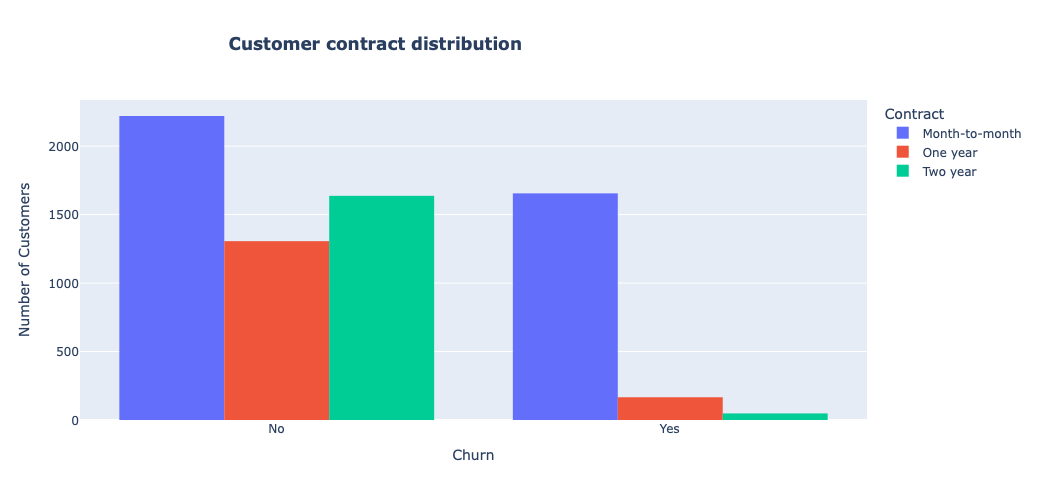

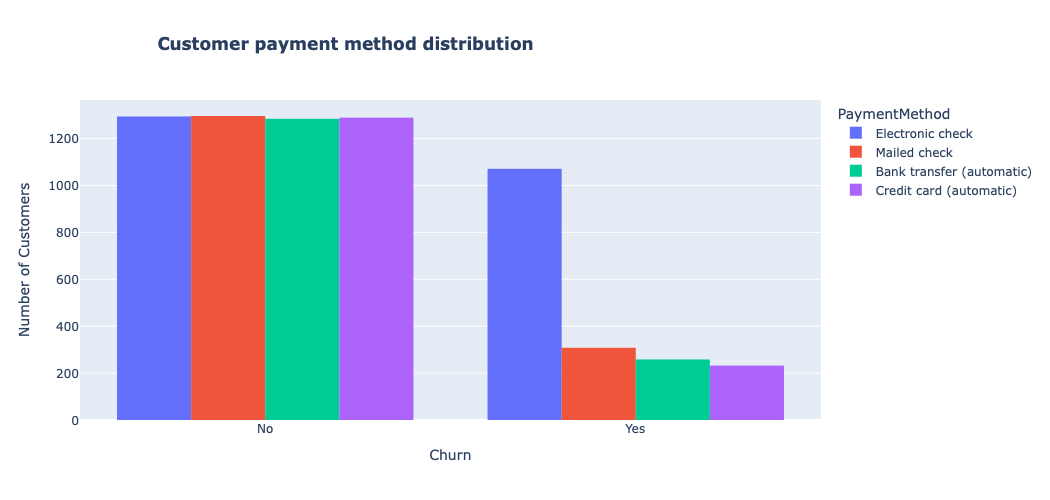

In [29]:
# ----- CONTRACT TYPE -----
fig = px.histogram(df, x="Churn", color="Contract", barmode="group", 
                   title="<b>Customer contract distribution</b>"
                   # histnorm="percent"
                  )
# for percentage:
# fig.update_traces(hovertemplate="%{y:.2f}%")

fig.update_layout(
    xaxis_title="Churn",
    yaxis_title="Number of Customers"
)
fig.update_layout(width=700, height=500, bargap=0.2)
fig.update_layout(title_x=0.22)
fig.show()


# ----- PAYMENT METHOD -----
fig = px.histogram(df, x="Churn", color="PaymentMethod", 
                   barmode="group", 
                   title="<b>Customer payment method distribution</b>", 
                  )

fig.update_layout(
    xaxis_title="Churn",
    yaxis_title="Number of Customers"
)
fig.update_layout(width=750, height=500, bargap=0.2)
fig.update_layout(title_x=0.15)
fig.show()

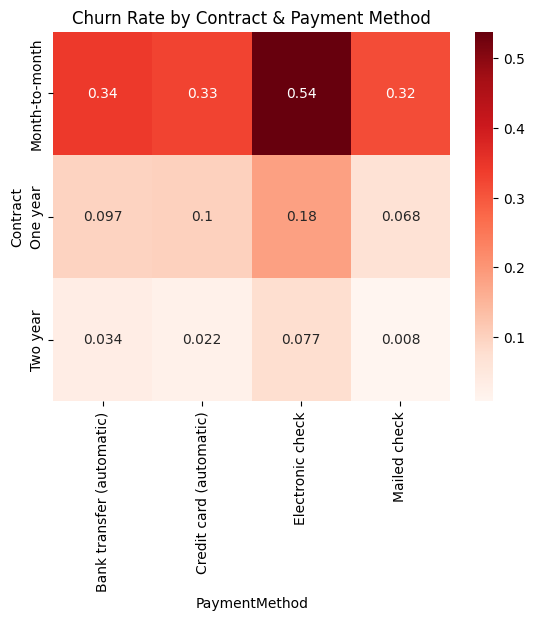

In [30]:
churn_rate = df.groupby(['Contract', 'PaymentMethod'])['Churn'].apply(lambda x: (x == 'Yes').mean()).unstack()

sns.heatmap(churn_rate, annot=True, cmap="Reds")
plt.title("Churn Rate by Contract & Payment Method")
plt.show()

In [31]:
df["InternetService"].describe()

count            7032
unique              3
top       Fiber optic
freq             3096
Name: InternetService, dtype: object

In [32]:
df.groupby('InternetService')['Churn'].value_counts().unstack()

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [33]:
pd.crosstab(
    [df["gender"], df["InternetService"]],
    df["Churn"]
)

Churn                    No  Yes
gender InternetService          
Female DSL              965  219
       Fiber optic      889  664
       No               690   56
Male   DSL              992  240
       Fiber optic      910  633
       No               717   57

In [34]:
fig = px.histogram(
    df,
    x="Churn",
    color="InternetService",
    facet_col="gender",
    barmode="group",
    histnorm="percent",
    facet_col_spacing=0.1,
    title="Customer Churn by Internet Service and Gender"
)
fig.update_layout(width=1000, height=450) 
fig.show()

In [35]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64

In [36]:
df[["SeniorCitizen","Churn"]].value_counts().unstack()

Churn,No,Yes
SeniorCitizen,,
No,4497,1393
Yes,666,476


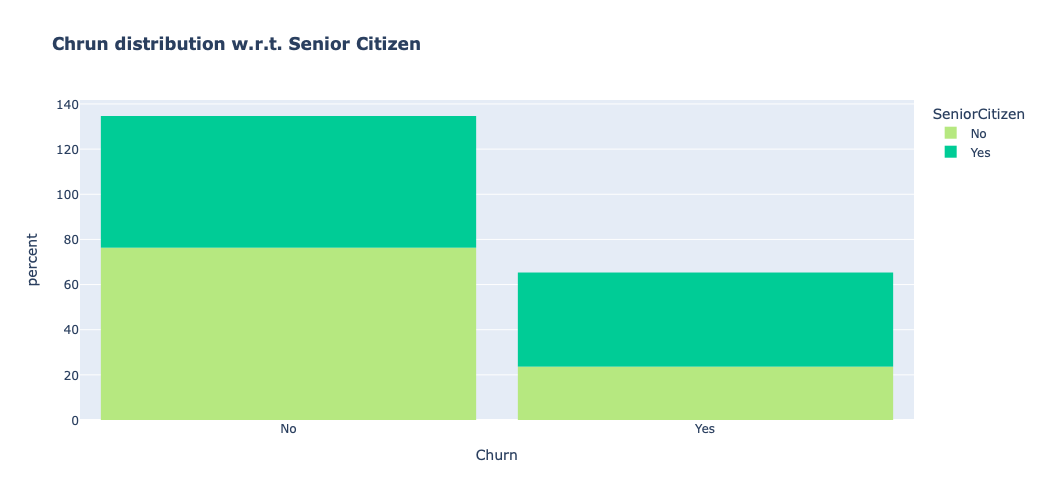

In [37]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}

fig = px.histogram(df, x="Churn", color="SeniorCitizen", 
                   title="<b>Chrun distribution w.r.t. Senior Citizen</b>", 
                   histnorm="percent",
                   color_discrete_map=color_map)

fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [38]:
df[["Dependents", "Churn"]].value_counts().unstack()

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1773,326


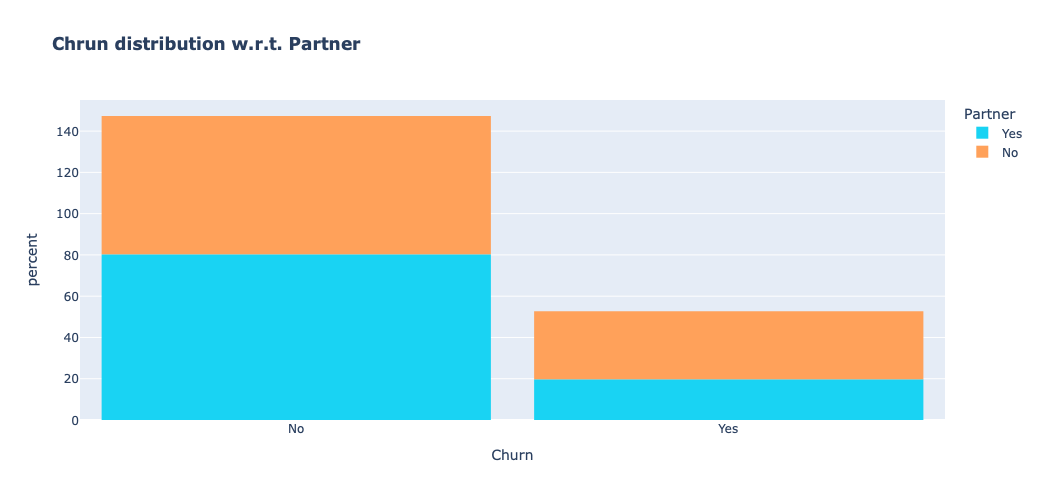

In [39]:
color_map = {"Yes": '#19D3F3', "No": '#FFA15A'}

fig = px.histogram(df, x="Churn", color="Partner", 
                   title="<b>Chrun distribution w.r.t. Partner</b>", 
                   histnorm="percent",
                   color_discrete_map=color_map)

fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [40]:
color_map = {"Yes": '#636EFA', "No": '#AB63FA'}

fig = px.histogram(df, x="Churn", color="Dependents", 
                   title="<b>Chrun distribution w.r.t. Dependents</b>", 
                   histnorm="percent",
                   color_discrete_map=color_map)

fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [41]:
df[["TechSupport", "Churn"]].value_counts().unstack()

Churn,No,Yes
TechSupport,,
No,2026,1446
No internet service,1407,113
Yes,1730,310


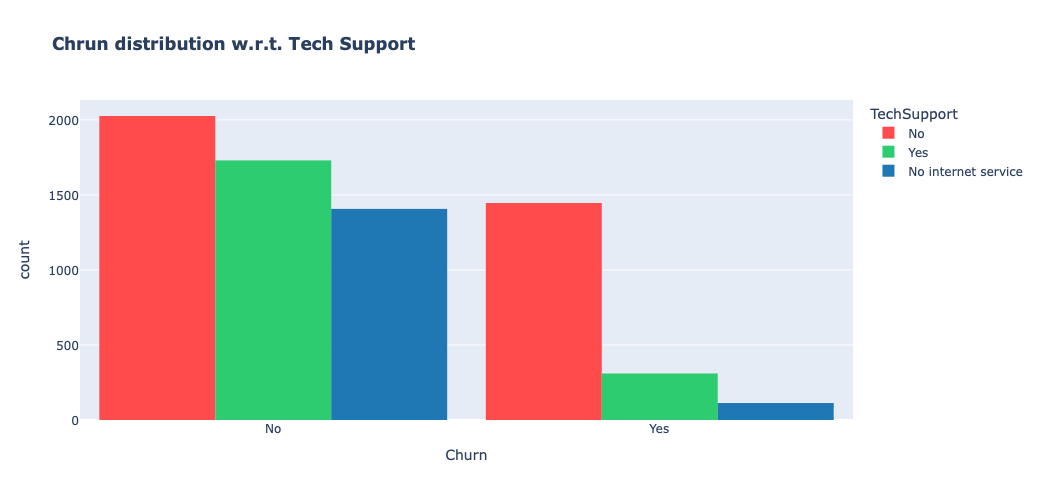

In [42]:
color_map = {"No": '#FF4B4B', "No internet service": '#1F77B4', "Yes": '#2ECC71'}

fig = px.histogram(df, x="Churn", color="TechSupport", 
                   title="<b>Chrun distribution w.r.t. Tech Support</b>", 
                   barmode="group",
                   color_discrete_map=color_map)

fig.update_layout(width=700, height=500, bargap=0.1)

fig.show()

In [43]:
df[["PhoneService", "Churn"]].value_counts().unstack()

Churn,No,Yes
PhoneService,,
No,510,170
Yes,4653,1699


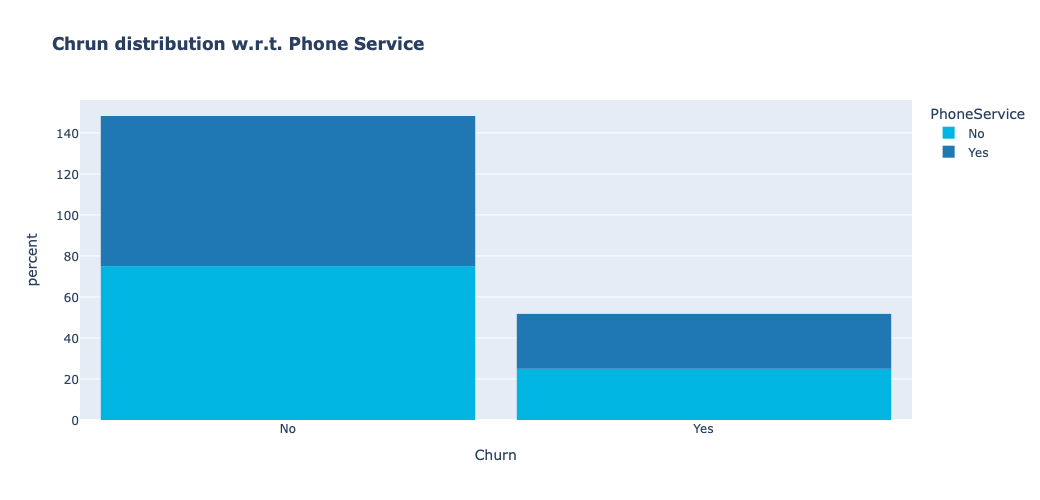

In [44]:
color_map = {"Yes": '#1F77B4', "No": '#00B5E2'}

fig = px.histogram(df, x="Churn", color="PhoneService",
                   title="<b>Chrun distribution w.r.t. Phone Service</b>", 
                   color_discrete_map=color_map,
                   histnorm="percent",)

fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [45]:
df[["MultipleLines","Churn"]].value_counts().unstack()

Churn,No,Yes
MultipleLines,,
No,2536,849
No phone service,510,170
Yes,2117,850


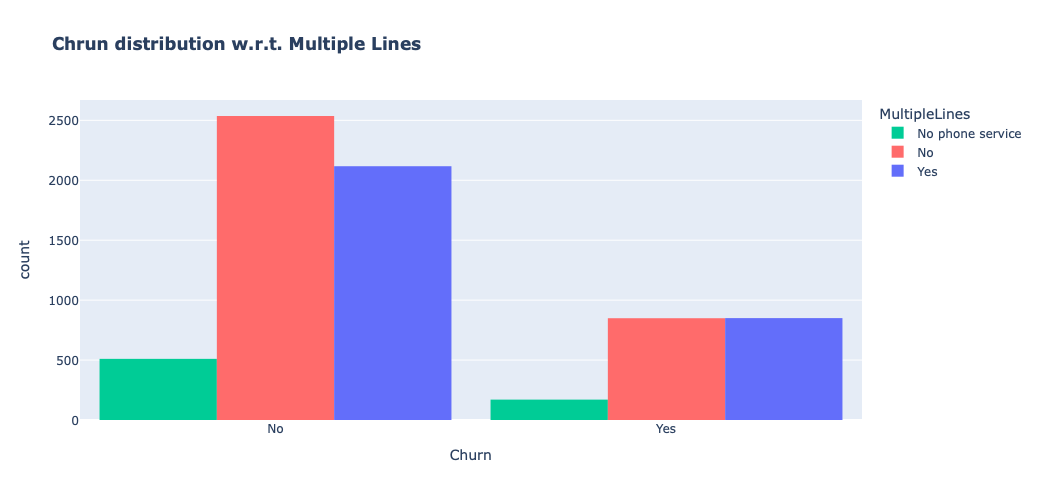

In [46]:
color_map = {"No": '#FF6B6B', "No phone service": '#00CC96', "Yes": '#636EFA'}

fig = px.histogram(df, x="Churn", color="MultipleLines", 
                   title="<b>Chrun distribution w.r.t. Multiple Lines</b>", 
                   barmode="group",
                   color_discrete_map=color_map)

fig.update_layout(width=700, height=500, bargap=0.1)

fig.show()

In [47]:
df[["PaperlessBilling","Churn"]].value_counts().unstack()

Churn,No,Yes
PaperlessBilling,,
No,2395,469
Yes,2768,1400


In [48]:
color_map = {"Yes": '#FFD93D', "No": '#FF6B6B'}

fig = px.histogram(df, x="Churn", color="PaperlessBilling",
                   title="<b>Chrun distribution w.r.t. Paperless Billing</b>", 
                   color_discrete_map=color_map,
                   histnorm="percent",)

fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [49]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [50]:
df[["DeviceProtection","Churn"]].value_counts().unstack()

Churn,No,Yes
DeviceProtection,,
No,1883,1211
No internet service,1407,113
Yes,1873,545


In [51]:
color_map = {"No": '#FFB6C1', "No internet service": '#ADD8E6', "Yes": '#90EE90'}

fig = px.histogram(df, x="Churn", color="DeviceProtection", 
                   title="<b>Chrun distribution w.r.t. Device Protection</b>", 
                   barmode="group",
                   color_discrete_map=color_map)

fig.update_layout(width=700, height=500, bargap=0.1)

fig.show()

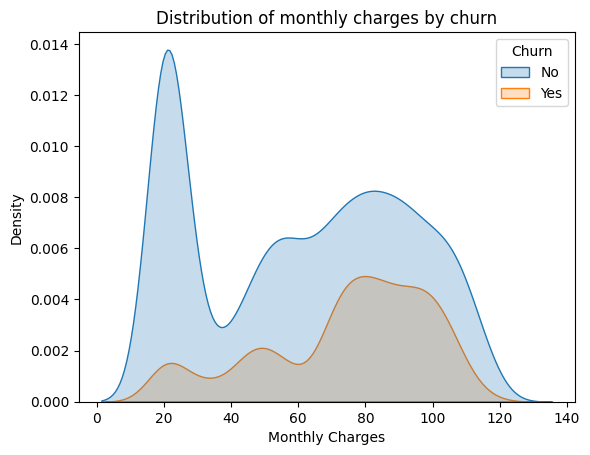

In [52]:
kde = sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True)
kde.set_ylabel('Density')
kde.set_xlabel('Monthly Charges')
kde.set_title('Distribution of monthly charges by churn')
plt.show()

In [53]:
# tenure: Number of months the customer has stayed with the company
df["tenure"].head(10)

0     1
1    34
2     2
3    45
4     2
5     8
6    22
7    10
8    28
9    62
Name: tenure, dtype: int64

In [54]:
fig = px.histogram(df, x="tenure", color="Churn",
                   title="<b>Chrun distribution w.r.t. Paperless Billing</b>"
                  )

fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [55]:
color_map = {"Yes": "#EF553B", "No": "#00CC96"}

fig = px.box(df, x='Churn', y = 'tenure',color='Churn',color_discrete_map=color_map)

fig.update_yaxes(title_text='Tenure (Months)')

fig.update_xaxes(title_text='Churn')

fig.update_layout(autosize=True, 
                  width=750, height=600,
                  title_font=dict(size=25, family='Courier'),
                  title='<b>Tenure vs Churn</b>',
)

fig.show()

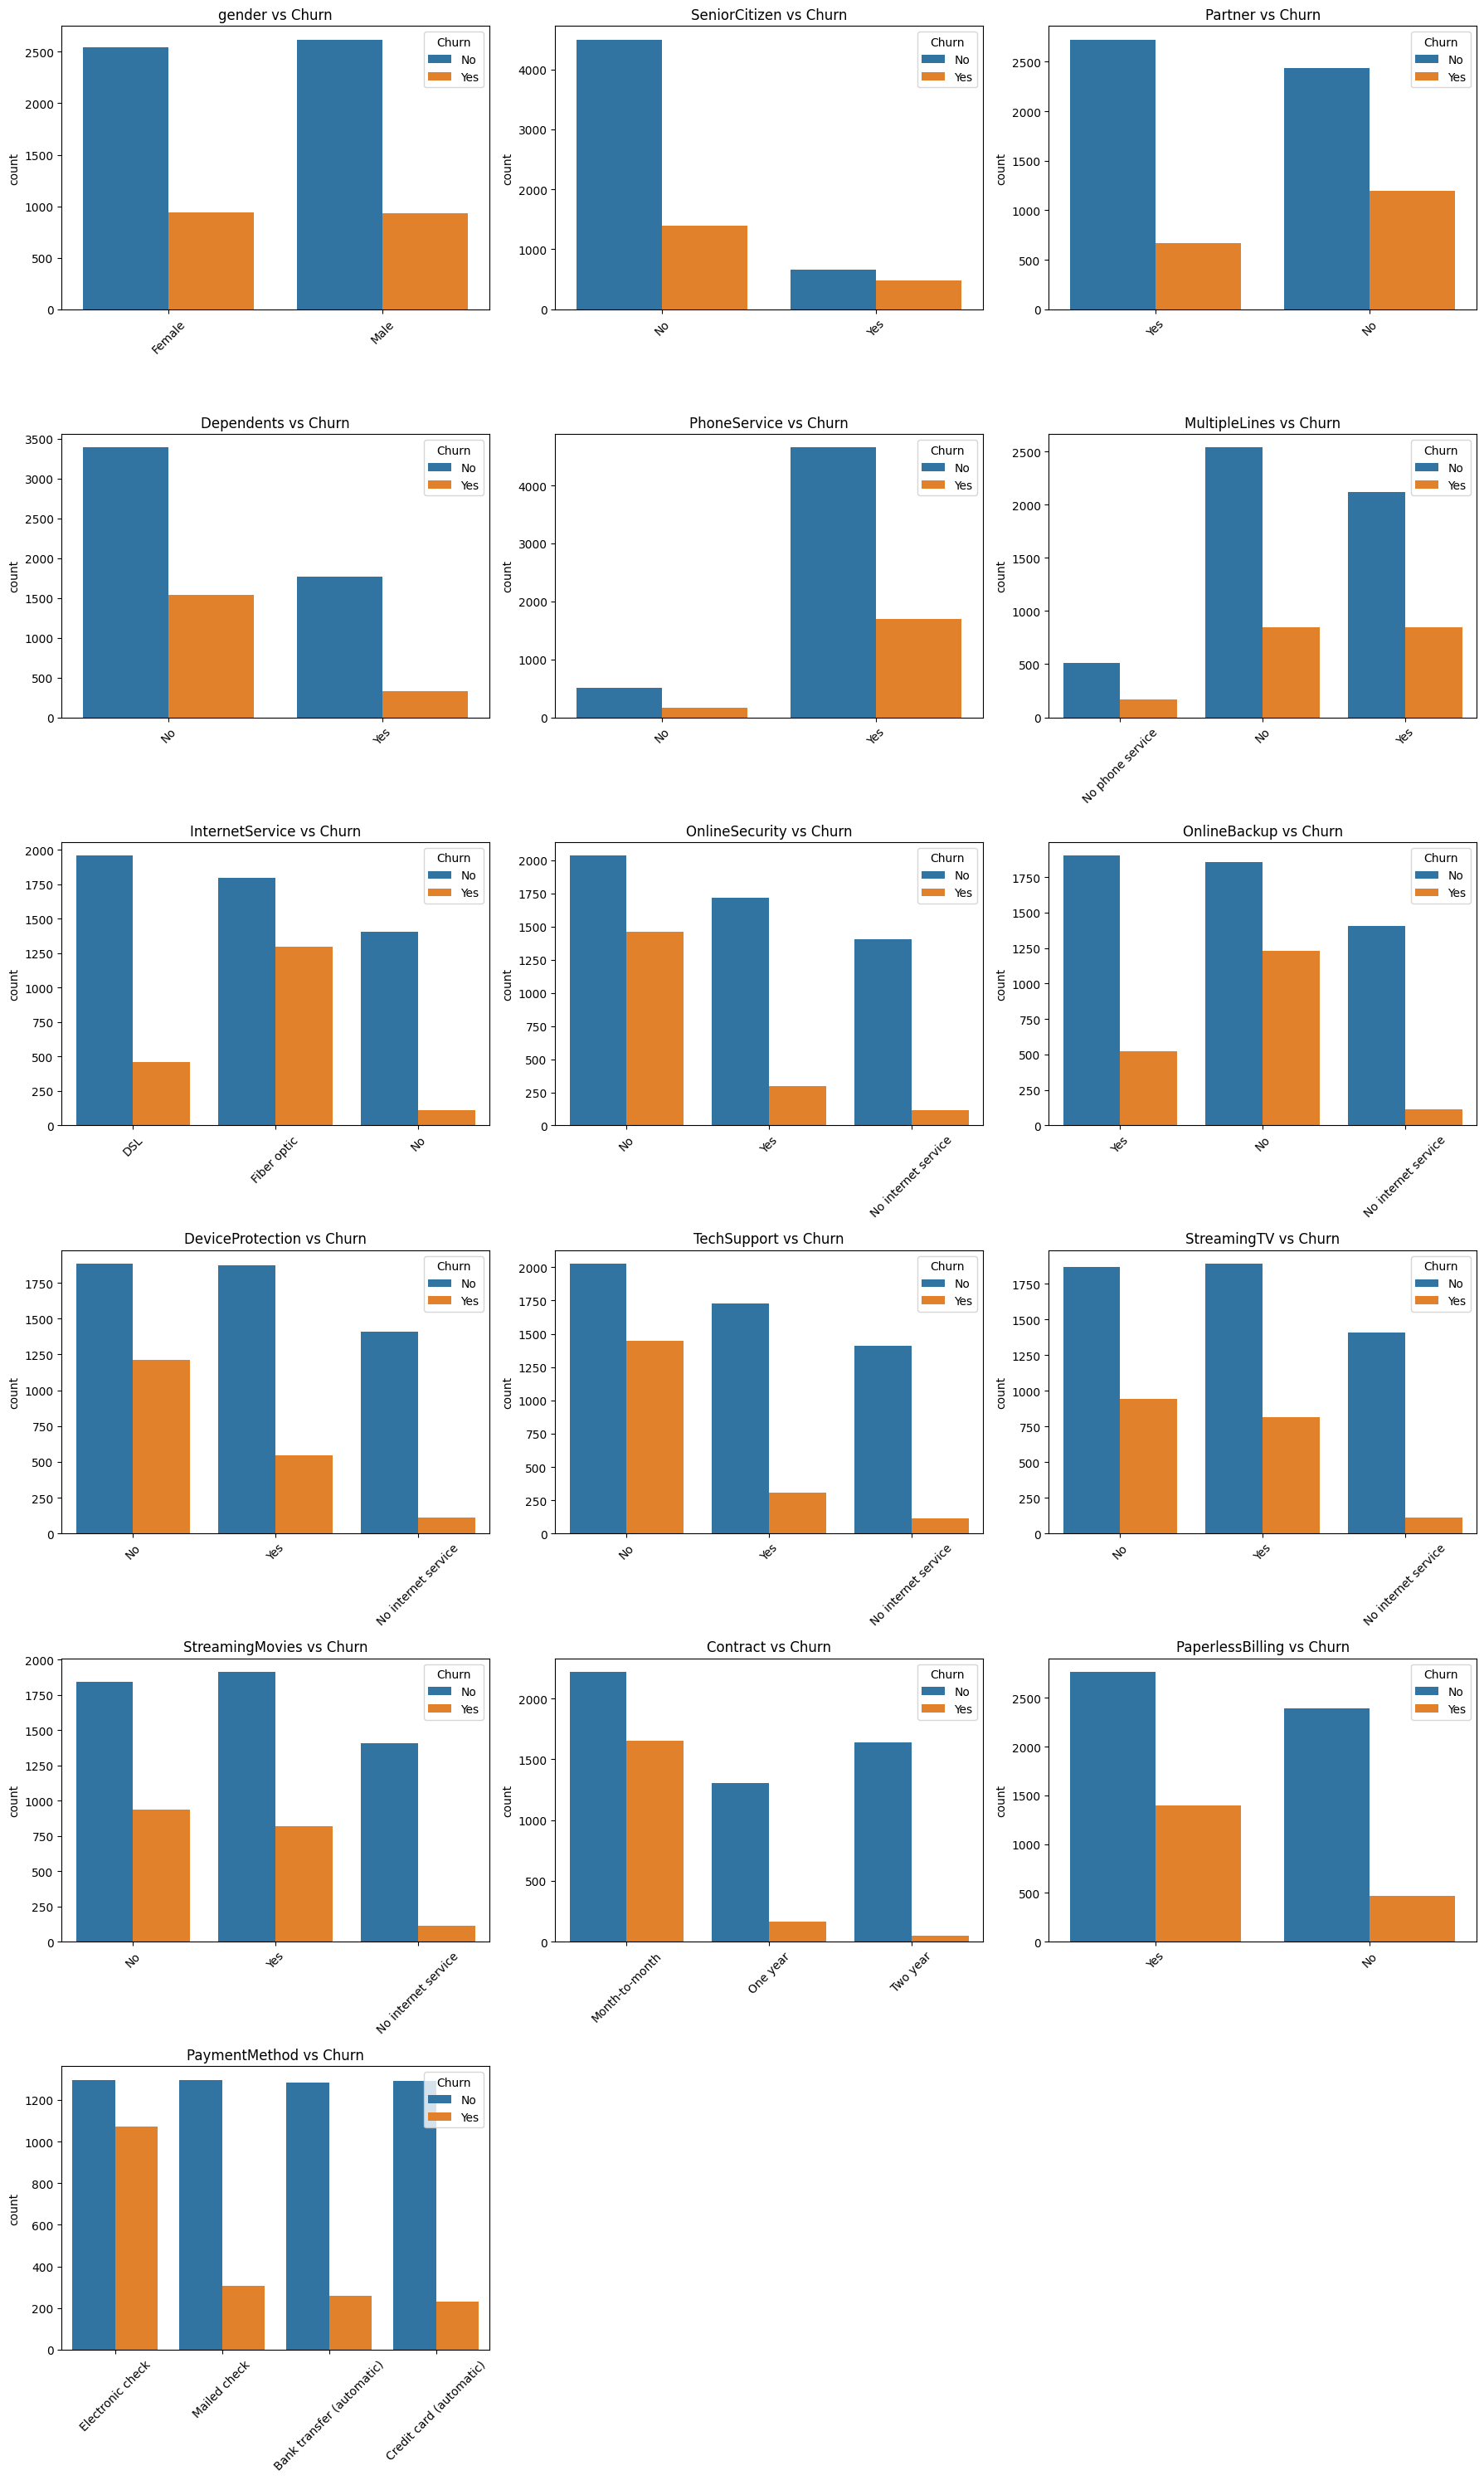

In [56]:
# Define categorical columns (excluding Churn)
cat_cols = [col for col in df.columns 
            if df[col].dtype == 'object' and col != 'Churn']

# Calculate grid size
n = len(cat_cols)
nrows = (n + 2) // 3   # 3 columns per row
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5*nrows))
axes = axes.flatten()   # Makes it easier to iterate

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i])
    axes[i].set_title(f'{col} vs Churn', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
    
# Hide any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [57]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [58]:
# Convert target to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Define features and target
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [59]:
#  Feature Engineering 

df['tenure_group'] = pd.cut(df['tenure'], 
                           bins=[0,12,24,48,72], 
                           labels=['0-1yr','1-2yr','2-4yr','4+yr'])

df['MonthlyCharges_group'] = pd.cut(df['MonthlyCharges'], 
                                   bins=[0,35,60,85,120], 
                                   labels=['Low','Medium','High','Very High'])

df['AvgMonthlyCharges'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
df['HighValueCustomer'] = (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)).astype(int)

print("Feature Engineering Completed")

Feature Engineering Completed


In [60]:
# Identify column types

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Features: {num_cols}")
print(f"\nCategorical Features: {cat_cols}")

Numerical Features: ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [61]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(
            drop='first', 
            sparse_output=False, 
            handle_unknown='ignore'
        ), cat_cols)
    ],
    remainder='passthrough'
)

# better compatibility with LightGBM / XGBoost
preprocessor.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

In [62]:
# Split the data (stratified to handle imbalance, this ensure same % of churn in train and test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 5625
Testing samples: 1407


In [63]:
# ---------- Logistic Regression ----------

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr_custom = (y_proba_lr > 0.3).astype(int)

print("-" * 55+"\nLogistic Regression\n"+"-" * 55)
print("Default Threshold (0.5)")
print(classification_report(y_test, y_pred_lr))
print(f"\n\nROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"\nCV ROC-AUC: {cross_val_score(lr_pipeline, X, y, cv=5, scoring='roc_auc').mean():.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_lr)}")

print("\n\nCustom Threshold (0.3) — Better Recall")
print(classification_report(y_test, y_pred_lr_custom))

-------------------------------------------------------
Logistic Regression
-------------------------------------------------------
Default Threshold (0.5)
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



ROC-AUC: 0.8353

Accuracy: 0.7257

CV ROC-AUC: 0.8451

Confusion Matrix:
[[724 309]
 [ 77 297]]


Custom Threshold (0.3) — Better Recall
              precision    recall  f1-score   support

           0       0.95      0.52      0.68      1033
           1       0.41      0.93      0.57       374

    accuracy                           0.63      1407
   macro avg       0.68      0.73      0.63      1407
weighted avg       0.81      0.63      0.65      1407



In [64]:
# ---------- Random Forest ----------

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
])
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]
y_pred_rf_custom = (y_proba_rf > 0.3).astype(int)

print("-" * 55+"\nRandom Forest\n"+"-" * 55)

print("Default Threshold (0.5)")
print(classification_report(y_test, y_pred_rf))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\nCV ROC-AUC: {cross_val_score(rf_pipeline, X, y, cv=5, scoring='roc_auc').mean():.4f}")
print(f"\n\Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")

print("\n\nCustom Threshold (0.3) — Better Recall")
print(classification_report(y_test, y_pred_rf_custom))

-------------------------------------------------------
Random Forest
-------------------------------------------------------
Default Threshold (0.5)
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.77      1407


ROC-AUC: 0.8179

Accuracy: 0.7854

CV ROC-AUC: 0.8252

\Confusion Matrix:
[[928 105]
 [197 177]]


Custom Threshold (0.3) — Better Recall
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.52      0.73      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



In [65]:
# ---------- XGBoost ----------

scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])
xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
y_pred_xgb_custom = (y_proba_xgb > 0.3).astype(int)

print("-" * 55+"\nXGBoost\n"+"-" * 55)

print("Default Threshold (0.5)")
print(classification_report(y_test, y_pred_xgb))
print(f"\n\nROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"\nCV ROC-AUC: {cross_val_score(xgb_pipeline, X, y, cv=5, scoring='roc_auc').mean():.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_xgb)}")

print("\n\nCustom Threshold (0.3) — Better Recall")
print(classification_report(y_test, y_pred_xgb_custom))

-------------------------------------------------------
XGBoost
-------------------------------------------------------
Default Threshold (0.5)
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.51      0.77      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.74      0.76      1407



ROC-AUC: 0.8260

Accuracy: 0.7448

CV ROC-AUC: 0.8381

Confusion Matrix:
[[761 272]
 [ 87 287]]


Custom Threshold (0.3) — Better Recall
              precision    recall  f1-score   support

           0       0.92      0.61      0.73      1033
           1       0.44      0.86      0.58       374

    accuracy                           0.67      1407
   macro avg       0.68      0.73      0.66      1407
weighted avg       0.79      0.67      0.69      1407



In [66]:
# ---------- LightGBM ----------

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        scale_pos_weight=scale,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])
lgbm_pipeline.fit(X_train, y_train)

y_pred_lgbm    = lgbm_pipeline.predict(X_test)
y_proba_lgbm   = lgbm_pipeline.predict_proba(X_test)[:, 1]
y_pred_lgbm_03 = (y_proba_lgbm > 0.3).astype(int)

print("-" * 55+"\nLightGBM\n"+"-" * 55)

print("Default Threshold (0.5)")
print(classification_report(y_test, y_pred_lgbm))
print(f"\n\nROC-AUC: {roc_auc_score(y_test, y_proba_lgbm):.4f}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"\nCV ROC-AUC: {cross_val_score(lgbm_pipeline, X, y, cv=5, scoring='roc_auc').mean():.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_lgbm)}")

print("\n\nCustom Threshold (0.3) — Better Recall")
print(classification_report(y_test, y_pred_lgbm_03))

-------------------------------------------------------
LightGBM
-------------------------------------------------------
Default Threshold (0.5)
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.75      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



ROC-AUC: 0.8270

Accuracy: 0.7427

CV ROC-AUC: 0.8362

Confusion Matrix:
[[763 270]
 [ 92 282]]


Custom Threshold (0.3) — Better Recall
              precision    recall  f1-score   support

           0       0.92      0.63      0.75      1033
           1       0.45      0.85      0.59       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.80      0.69      0.71      1407



In [67]:
# -------------------- Model Comparison Summary --------------------

summary = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'ROC-AUC':  [roc_auc_score(y_test, y_proba_lr),
                 roc_auc_score(y_test, y_proba_rf),
                 roc_auc_score(y_test, y_proba_xgb),
                 roc_auc_score(y_test, y_proba_lgbm)],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_xgb),
                 accuracy_score(y_test, y_pred_lgbm)]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

              Model  ROC-AUC  Accuracy
Logistic Regression 0.835344  0.725657
           LightGBM 0.826969  0.742715
            XGBoost 0.826018  0.744847
      Random Forest 0.817928  0.785359


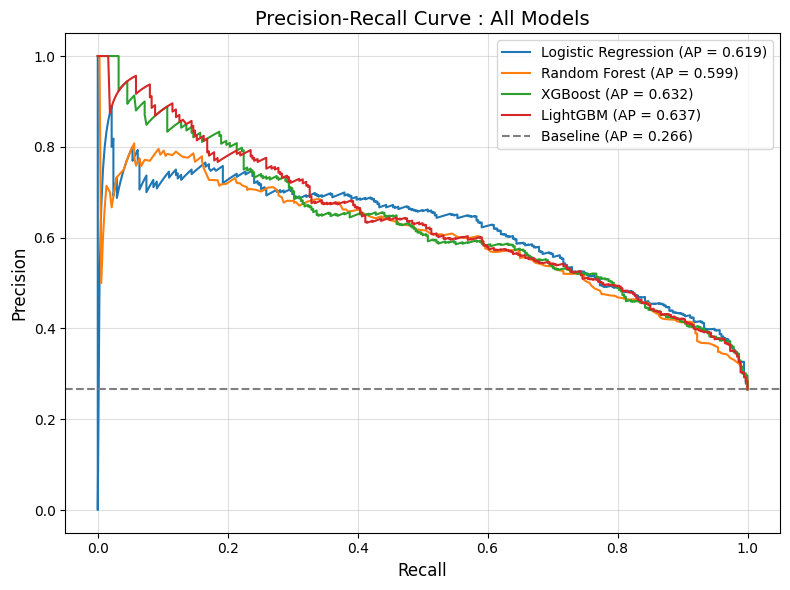

In [68]:
# -------------------- Precision-Recall Curve --------------------

model_probas = {
    'Logistic Regression': y_proba_lr,
    'Random Forest': y_proba_rf,
    'XGBoost': y_proba_xgb,
    'LightGBM': y_proba_lgbm
}

plt.figure(figsize=(8, 6))
for name, proba in model_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.axhline(y=y_test.mean(), color='gray', linestyle='--',
            label=f"Baseline (AP = {y_test.mean():.3f})")

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve : All Models", fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [69]:
# -------------------- Business metrics using xgb_pipeline --------------------

REVENUE_SAVED_PER_CHURNER_CAUGHT = 500
COST_PER_RETENTION_OFFER = 50

thresholds = np.arange(0.05, 0.9, 0.02)
results = []

for thresh in thresholds:
    y_pred_t = (y_proba_xgb >= thresh).astype(int)
    TP = ((y_pred_t == 1) & (y_test == 1)).sum()
    FP = ((y_pred_t == 1) & (y_test == 0)).sum()
    FN = ((y_pred_t == 0) & (y_test == 1)).sum()

    revenue_saved = TP * REVENUE_SAVED_PER_CHURNER_CAUGHT
    outreach_cost = (TP + FP) * COST_PER_RETENTION_OFFER
    net_value = revenue_saved - outreach_cost

    results.append({
        'Threshold': thresh,
        'TP': TP, 
        'FP': FP, 
        'FN': FN,
        'Revenue Saved ($)': revenue_saved,
        'Outreach Cost ($)': outreach_cost,
        'Net Value ($)': net_value
    })

bm_df = pd.DataFrame(results)
best = bm_df.loc[bm_df['Net Value ($)'].idxmax()]

print("-" * 60+"\nBusiness Metrics : OPTIMAL THRESHOLD ANALYSIS (XGBoost)\n"+"-" * 60)

print(f"Best Threshold     : {best['Threshold']:.3f}")
print(f"Churners Caught    : {best['TP']}")
print(f"False Alarms       : {best['FP']}")
print(f"Missed Churners    : {best['FN']}")
print(f"Revenue Saved      : ${best['Revenue Saved ($)']:,.0f}")
print(f"Outreach Cost      : ${best['Outreach Cost ($)']:,.0f}")
print(f"Net Value          : ${best['Net Value ($)']:,.0f}")
print(f"{'-'*60}")

------------------------------------------------------------
Business Metrics : OPTIMAL THRESHOLD ANALYSIS (XGBoost)
------------------------------------------------------------
Best Threshold     : 0.090
Churners Caught    : 364.0
False Alarms       : 624.0
Missed Churners    : 10.0
Revenue Saved      : $182,000
Outreach Cost      : $49,400
Net Value          : $132,600
------------------------------------------------------------


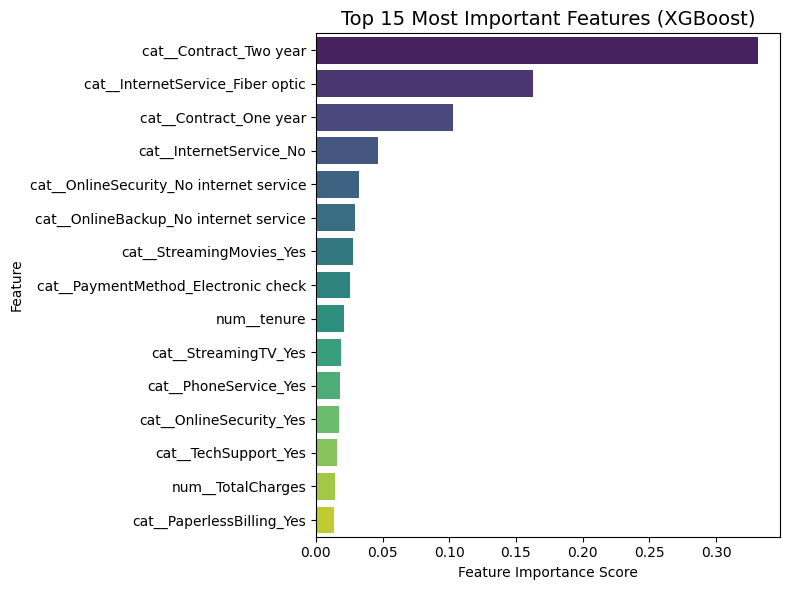


                                     Feature  Importance
25                   cat__Contract_Two year    0.331274
10         cat__InternetService_Fiber optic    0.163053
24                   cat__Contract_One year    0.103067
11                  cat__InternetService_No    0.046422
12  cat__OnlineSecurity_No internet service    0.032674
14    cat__OnlineBackup_No internet service    0.029021
23                 cat__StreamingMovies_Yes    0.027557
28      cat__PaymentMethod_Electronic check    0.025366
0                               num__tenure    0.021500
21                     cat__StreamingTV_Yes    0.018823
7                     cat__PhoneService_Yes    0.017948
13                  cat__OnlineSecurity_Yes    0.017698
19                     cat__TechSupport_Yes    0.016040
2                         num__TotalCharges    0.014633
26                cat__PaperlessBilling_Yes    0.013555


In [70]:
# -------------------- Feature Importance : XG BOOST --------------------

# Get feature names after preprocessing
feature_names_xgb = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get importance from XGBoost
importances = xgb_pipeline.named_steps['classifier'].feature_importances_

# Create a DF
feat_imp_df = pd.DataFrame({
    'Feature': feature_names_xgb,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', hue='Feature', palette='viridis')
plt.title('Top 15 Most Important Features (XGBoost)', fontsize=14)
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("\n",feat_imp_df)

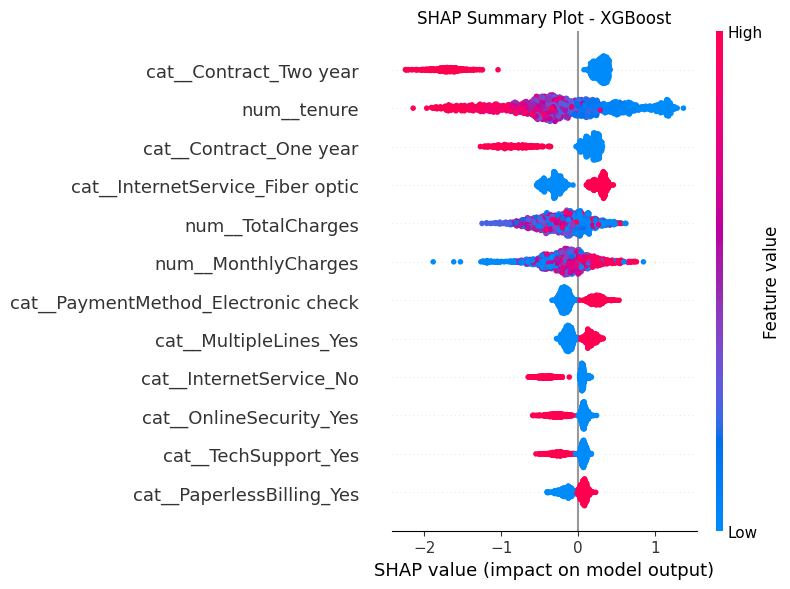

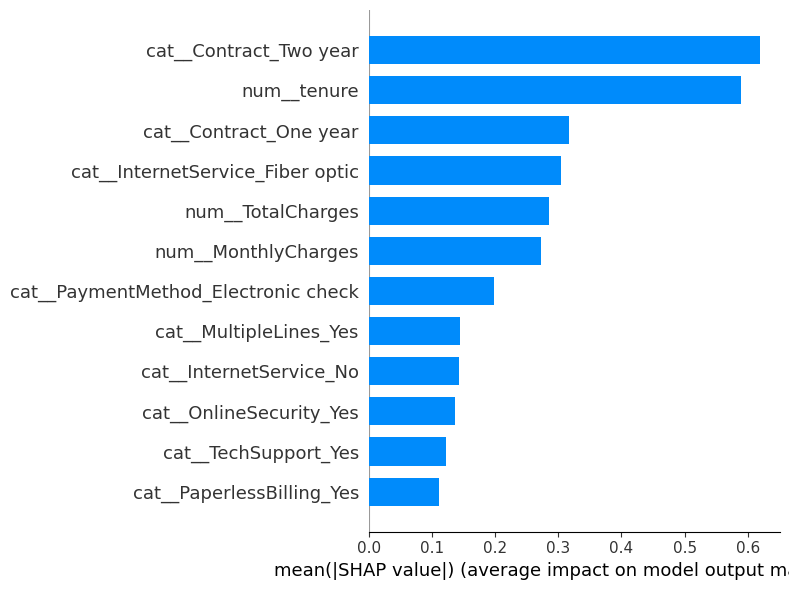

In [71]:
# -------------------- SHAP Values (XGBoost) --------------------

# Create SHAP Explainer
explainer = shap.TreeExplainer(xgb_pipeline.named_steps['classifier'])

# Transform test data
X_test_transformed = xgb_pipeline.named_steps['preprocessor'].transform(X_test)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# Summary Plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names_xgb, 
                  max_display=12, show=False)
plt.title("SHAP Summary Plot - XGBoost", fontsize=12)
plt.gcf().set_size_inches(8, 6)
plt.tight_layout()
plt.show()

print("\n")

# Bar plot : magnitude
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=feature_names_xgb, max_display=12, plot_type="bar",show=False
)
plt.gcf().set_size_inches(8, 6)
plt.tight_layout()
plt.show()

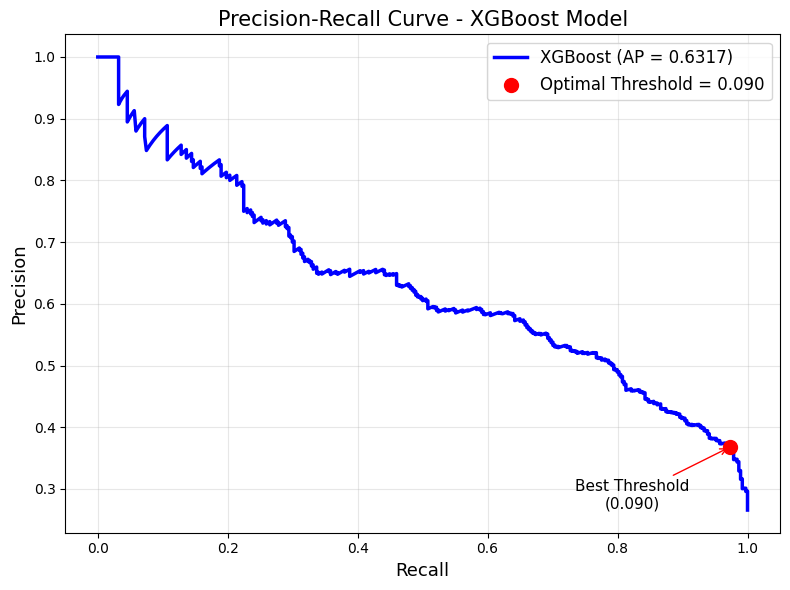


Average Precision (AP) Score:            0.6317
Precision at Optimal Threshold (0.090):  0.3680
Recall at Optimal Threshold (0.090):     0.9733


In [72]:
# -------------------- Precision-Recall Curve for XG Boost --------------------

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)

# Average Precision Score (AP)
ap_score = average_precision_score(y_test, y_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2.5, color='blue', label=f'XGBoost (AP = {ap_score:.4f})')

# Highlighting the optimal threshold found earlier from business metrics
optimal_thresh = best['Threshold'] if 'best' in locals() else 0.3
idx = np.argmin(np.abs(thresholds - optimal_thresh))

plt.scatter(recall[idx], precision[idx], color='red', s=100, label=f'Optimal Threshold = {optimal_thresh:.3f}', zorder=5)

plt.annotate(f'Best Threshold\n({optimal_thresh:.3f})', 
             xy=(recall[idx], precision[idx]), 
             xytext=(recall[idx]-0.15, precision[idx]-0.1),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=11, ha='center')

plt.title('Precision-Recall Curve - XGBoost Model', fontsize=15)
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Summary
print(f"\nAverage Precision (AP) Score:            {ap_score:.4f}")
print(f"Precision at Optimal Threshold ({optimal_thresh:.3f}):  {precision[idx]:.4f}")
print(f"Recall at Optimal Threshold ({optimal_thresh:.3f}):     {recall[idx]:.4f}")

In [73]:
# -------------------- Conclusion and Recommendation --------------------

print("-" * 60+"\nProject Summary and Recommendations\n"+"-" * 60)

print(f"""

Model Selected : XGBoost

Performance Highlights :

- ROC-AUC            : {roc_auc_score(y_test, y_proba_xgb):.4f}
- Best Threshold     : {best['Threshold']:.3f}
- Expected Net Value : ${best['Net Value ($)']:,.0f}


Key Business Insights : 

1. Customers on month-to-month contracts are far more likely to churn than those on longer plans.
2. Tenure matters a lot, newer customers are significantly more at risk.
3. Monthly charges are a strong signal, higher bills often correlate with higher churn risk.
4. The most vulnerable segment is: High-paying, newer customers
5. There are also clear risk pockets among:
     - Customers using Fiber optic services
     - Customers without tech support
   Offering incentives to Fiber optic users and customers without Tech Support can reduce churn.


Recommended Actions :

- Target customers with Month-to-month contracts + high MonthlyCharges for retention offers.
- Use a decision threshold of {best['Threshold']:.3f} in production to strike a good balance between catching churn and avoiding unnecessary costs.
- Proactively engage:
     * New customers early in their lifecycle
     * High-value customers showing churn signals
- Consider:
     * Incentives or bundled offers for Fiber optic users
     * Promoting or including tech support as a retention lever


Operational recommendation : 

- Deploy this model for churn scoring
- Retrain it every 1–2 months to keep predictions accurate as customer behavior evolves     

""")

# Optional: Save the final model
import joblib
joblib.dump(xgb_pipeline, 'final_xgboost_churn_model.pkl')
print("Final XGBoost model saved as 'final_xgboost_churn_model.pkl'")

------------------------------------------------------------
Project Summary and Recommendations
------------------------------------------------------------


Model Selected : XGBoost

Performance Highlights :

- ROC-AUC            : 0.8260
- Best Threshold     : 0.090
- Expected Net Value : $132,600


Key Business Insights : 

1. Customers on month-to-month contracts are far more likely to churn than those on longer plans.
2. Tenure matters a lot, newer customers are significantly more at risk.
3. Monthly charges are a strong signal, higher bills often correlate with higher churn risk.
4. The most vulnerable segment is: High-paying, newer customers
5. There are also clear risk pockets among:
     - Customers using Fiber optic services
     - Customers without tech support
   Offering incentives to Fiber optic users and customers without Tech Support can reduce churn.


Recommended Actions :

- Target customers with Month-to-month contracts + high MonthlyCharges for retention offers.


In [74]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,MonthlyCharges_group,AvgMonthlyCharges,HighValueCustomer
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1yr,Low,29.850000,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,0,2-4yr,Medium,55.573529,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1yr,Medium,54.075000,0
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4yr,Medium,40.905556,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1yr,High,75.825000,0


In [75]:
from sqlalchemy import create_engine

# Create df with predictions 
df_copy = df.copy()

# Get predictions for all customers using the trained pipeline
full_predictions = xgb_pipeline.predict_proba(df_copy)[:, 1]

# Add prediction columns
df_copy['Churn_Probability'] = full_predictions
df_copy['Predicted_Churn'] = (full_predictions >= best['Threshold']).astype(int)
df_copy['High_Risk_Customer'] = df_copy['Churn_Probability'] >= 0.5

# Add business value columns
df_copy['Expected_Revenue_Saved'] = df_copy['Predicted_Churn'] * 500
df_copy['Retention_Cost'] = df_copy['Predicted_Churn'] * 50
df_copy['Net_Value'] = df_copy['Expected_Revenue_Saved'] - df_copy['Retention_Cost']

print(f"Dataset : {df_copy.shape[0]} rows, {df_copy.shape[1]} columns")

Dataset : 7032 rows, 30 columns


In [76]:
username = 'postgres'
password = 'connect123'
host = 'localhost'
port = '5432'
database = 'customer_churn_dataset'

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

df_copy.to_sql('customer_churn_predictions', 
               con=engine, 
               if_exists='replace', 
               index=False, 
               method='multi')

print("Data is successfully loaded into the table.")
print("Table name: customer_churn_predictions")
print(f"Total rows exported: {df_copy.shape[0]}")

Data is successfully loaded into the table.
Table name: customer_churn_predictions
Total rows exported: 7032
